In [3]:
"""
TASK 4: Impact of Weight w on Optimal Trajectories
============================================================
What this notebook is for: this notebook reuses the completed
solve_daily_qp() from Task 1 and sweeps the objective weight w across
several orders of magnitude to show how the optimal BESS/grid trajectories
shift between a customer-centric (savings-driven) mode and a grid-centric
(smoothing-driven) mode.

What you need to do in this notebook: type in the objective as what you have already completed in Task 1 objective.

Before you run this notebook, upload these two files to the Colab file
panel: perfect_load.csv and perfect_pv.csv.
"""

import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# SECTION: Data loading helpers (no changes needed, same as Task 1)
# ==============================================================================
def read_load_generation(load_file, pv_file):
    """
    Read load and generation from CSV files
    """
    df_load = pd.read_csv(load_file)
    df_pv = pd.read_csv(pv_file)

    dates = df_load.iloc[:, 0].astype(str).tolist()

    load_profiles = df_load.iloc[:, 1:].values.flatten()
    pv_profiles = df_pv.iloc[:, 1:].values.flatten()
    days = len(df_load)

    return load_profiles, pv_profiles, days, dates


def generate_eta_profiles(days, steps_per_day):
    """
    Generates the daily time-of-use tariff and copies it
    across the entire multi-day horizon.
    """
    eta_day = np.zeros(steps_per_day)
    eta_day[np.r_[0:14, 44:48]] = 0.03   # Off-peak rate ($/kWh)
    eta_day[np.r_[14:28, 40:44]] = 0.06  # Shoulder rate ($/kWh)
    eta_day[28:40]               = 0.30  # Peak rate ($/kWh)

    eta_profiles = np.tile(eta_day, days)
    return eta_profiles

# ==============================================================================
# SECTION: Core QP solver
# (This is the SAME objective you completed for Task 1. Type in the objective on your own.)
# ==============================================================================
def solve_daily_qp(p_load_day, p_pv_day, eta_day, z_init, steps_per_day, delta, p_min, p_max, c_max, w):
    x1 = cp.Variable(steps_per_day)  # BESS power (positive=discharge, negative=charge)
    x2 = cp.Variable(steps_per_day)  # Grid power (positive=import, negative=export)
    z  = cp.Variable(steps_per_day + 1)  # BESS SOC

    ### Completed Task 1 objective (do not modify):
    ###   min sum [ -delta * eta(k) * x1(k) + w * eta(k) * (x2(k))^2 ]
    objective = cp.Minimize(
    -delta * (eta_day @ x1)
    + w * cp.sum(cp.multiply(eta_day, cp.square(x2)))
)

    # QP constraints -- already implemented, do not modify.
    # =========================================================================
    # SOC dynamics -- why the code indexing differs from the LaTeX
    # -------------------------------------------------------------------------
    # LaTeX (initial SoC z(0), interval index k = 1..s):
    #     z(k) = z(k-1) - delta * x1(k),        z(s) = z(0)      [Eqs. 15c, 15f]
    #
    # The code arrays are 0-based, and z carries ONE extra slot for z(0):
    #     z[0 .. s]     <->  z(0), z(1), ..., z(s)    (length s+1;  z[0] = z(0))
    #     x1[0 .. s-1]  <->  x1(1), x1(2), ..., x1(s) (length s;  there is no x1(0))
    #   =>  z[k] = z(k)   but   x1[k] = x1(k+1)
    #
    # Re-indexing the LaTeX recurrence to these 0-based arrays gives:
    #     z[k+1] = z[k] - delta * x1[k],        k = 0 .. s-1
    # It is the SAME equation -- the loop is just shifted so x1's index lines up
    # with k, which is why the range starts at 0 (not 1) and there is no x1[k-1].
    # =========================================================================
    constraints = [
        x2 == p_load_day - p_pv_day - x1,       # Power balance
        x1 >= p_min, x1 <= p_max,               # BESS power limits
        z >= 0.0, z <= c_max,                    # BESS capacity boundaries
        z[0] == z_init                          # z[0] = z(0): initial SoC (see indexing note above)
    ]

    # SOC dynamics (0-based, loop-shifted -- see note above)
    for k in range(steps_per_day):            # k = 0..s-1 (0-based; see note above)
        constraints += [z[k+1] == z[k] - delta * x1[k]]

    # Daily periodic terminal constraint
    constraints += [z[steps_per_day] == z[0]]   # cyclic: z(s) = z(0)

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)

    if prob.status != cp.OPTIMAL:
        print(f"Warning: Daily subproblem optimization returned status: {prob.status}")
    # Exclude z[0], the fixed initial-energy boundary, so the returned
    # energy trajectory has one end-of-interval value per dispatch step.
    return x1.value, x2.value, z.value[1:]


# ==============================================================================
# SECTION: Multi-day batch loop (no changes needed, same as Task 1)
# ==============================================================================
def run_batch_loop(global_z_init, days, steps_per_day, total_horizon, delta, load_profiles, pv_profiles, eta_profiles, p_min, p_max, c_max, w):
    """
    Executes the multi-day batch loop and stitches isolated daily optimization cycles together.
    """
    all_x1_BESS = np.zeros(total_horizon)
    all_x2_grid = np.zeros(total_horizon)
    all_z_SOC   = np.zeros(total_horizon)

    current_z_init = global_z_init

    for d in range(days):
        start_idx = d * steps_per_day
        end_idx   = (d + 1) * steps_per_day

        # Extract 48-step horizons for the current batch cycle
        p_load_day = load_profiles[start_idx:end_idx]
        p_pv_day   = pv_profiles[start_idx:end_idx]
        eta_day    = eta_profiles[start_idx:end_idx]

        # Run QP for a single day
        x1_opt, x2_opt, z_opt = solve_daily_qp(
            p_load_day, p_pv_day, eta_day, current_z_init,
            steps_per_day, delta, p_min, p_max, c_max, w
        )

        # Stitch decision array results into global outputs
        all_x1_BESS[start_idx:end_idx] = x1_opt
        all_x2_grid[start_idx:end_idx] = x2_opt
        all_z_SOC[start_idx:end_idx]   = z_opt

        # State inheritance
        current_z_init = z_opt[-1]

    print("Batch QP Completed.")
    return all_x1_BESS, all_x2_grid, all_z_SOC


def plot_results(timeline_hours, load_profiles, pv_profiles, eta_profiles, all_x1_BESS, all_x2_grid, all_z_SOC, p_max, c_max, days, delta, dates):
    """
    (Not called in this notebook's main cell -- kept here in case you want to
    inspect a single w value's full result set the same way Task 1 does.)
    """
    plt.rcParams.update({
        'font.size': 13,
        'axes.labelsize': 14,
        'axes.titlesize': 15,
        'savefig.dpi': 300
    })

    total_hours = timeline_hours[-1] + delta
    tick_hours = np.arange(0, total_hours + 1, 6)

    time_labels = []
    for h in tick_hours:
        day_idx = int(h // 24)
        time_str = f"{int(h % 24):02d}:30"

        if h % 24 == 0 and day_idx < days:
            time_labels.append(f"{dates[day_idx]}\n{time_str}")
        else:
            time_labels.append(f"\n{time_str}")

    max_power_val = max(load_profiles.max(), pv_profiles.max(), all_x2_grid.max())
    min_power_val = min(load_profiles.min(), pv_profiles.min(), all_x2_grid.min(), -p_max)

    plt.figure(figsize=(14, 4))
    plt.plot(timeline_hours, eta_profiles, color='crimson', linestyle='-', linewidth=2.5,
             drawstyle='steps-post', label='Electricity Tariff ($/kWh)')
    for d in range(1, days):
        plt.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=2.5)
    plt.axvline(x=days * 24.0, color='red', linestyle=':', linewidth=2.5, label='Day Boundary')
    plt.title('Time-of-Use Electricity Tariff', y=1.05)
    plt.xlabel('Time Horizon')
    plt.ylabel('Tariff Rate ($/kWh)')
    plt.xlim(0, total_hours)
    plt.xticks(tick_hours, time_labels, rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(timeline_hours, load_profiles, color='black', linestyle='--', linewidth=2.0,
             drawstyle='steps-post', label='Residential Load (kW)')
    plt.plot(timeline_hours, pv_profiles, color='orange', linestyle='-', linewidth=2.0,
             drawstyle='steps-post', label='Solar PV Generation (kW)')
    for d in range(1, days):
        plt.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=2.5)
    plt.axvline(x=days * 24.0, color='red', linestyle=':', linewidth=2.5, label='Day Boundary')
    plt.title('Load and Generation Profiles', y=1.05)
    plt.xlabel('Time horizon')
    plt.ylabel('Active Power (kW)')
    plt.xlim(0, total_hours)
    plt.xticks(tick_hours, time_labels, rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(timeline_hours, all_x2_grid, color='blue', linestyle='-', linewidth=2.5,
             drawstyle='steps-post', label='Optimal Grid Power $x_2$ (kW)')
    plt.plot(timeline_hours, all_x1_BESS, color='green', linestyle='-.', linewidth=2.0,
             drawstyle='steps-post', label='Optimal BESS Power $x_1$ (kW)')
    for d in range(1, days):
        plt.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=2.5)
    plt.axvline(x=days * 24.0, color='red', linestyle=':', linewidth=2.5, label='Day Boundary')
    plt.title('Optimal Battery and Grid Power Under Batch QP', y=1.05)
    plt.xlabel('Time Horizon')
    plt.ylabel('Active Power (kW)')
    plt.xlim(0, total_hours)
    plt.xticks(tick_hours, time_labels, rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(timeline_hours, all_z_SOC, color='purple', linestyle='-', linewidth=3.0,
             drawstyle='steps-post', label='BESS SOC $z$ (kWh)')
    for d in range(1, days):
        plt.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=2.5)
    plt.axvline(x=days * 24.0, color='red', linestyle=':', linewidth=2.5, label='Day Boundary')
    plt.title('Battery SOC under Batch QP', y=1.05)
    plt.xlabel('Time Horizon')
    plt.ylabel('Battery SOC (kWh)')
    plt.xlim(0, total_hours)
    plt.xticks(tick_hours, time_labels, rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()


Solving batch QP for w = 1e-06 ...
Batch QP Completed.
Solving batch QP for w = 1e-05 ...
Batch QP Completed.
Solving batch QP for w = 1e-04 ...
Batch QP Completed.
Solving batch QP for w = 1e-03 ...
Batch QP Completed.
Solving batch QP for w = 1e-02 ...
Batch QP Completed.
Solving batch QP for w = 1e-01 ...
Batch QP Completed.
Solving batch QP for w = 1e+00 ...
Batch QP Completed.
Solving batch QP for w = 1e+01 ...
Batch QP Completed.


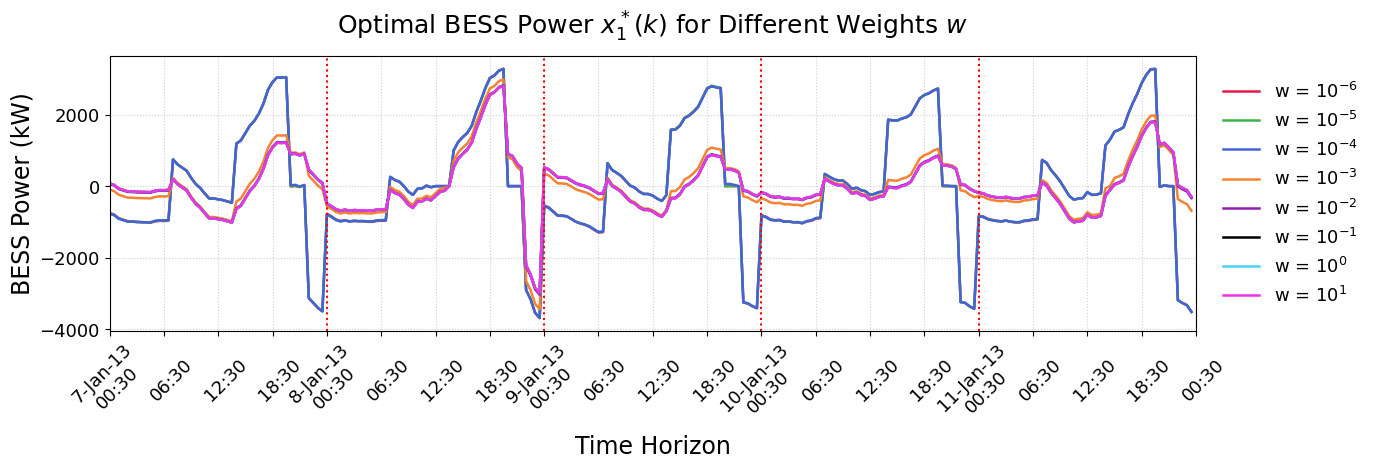

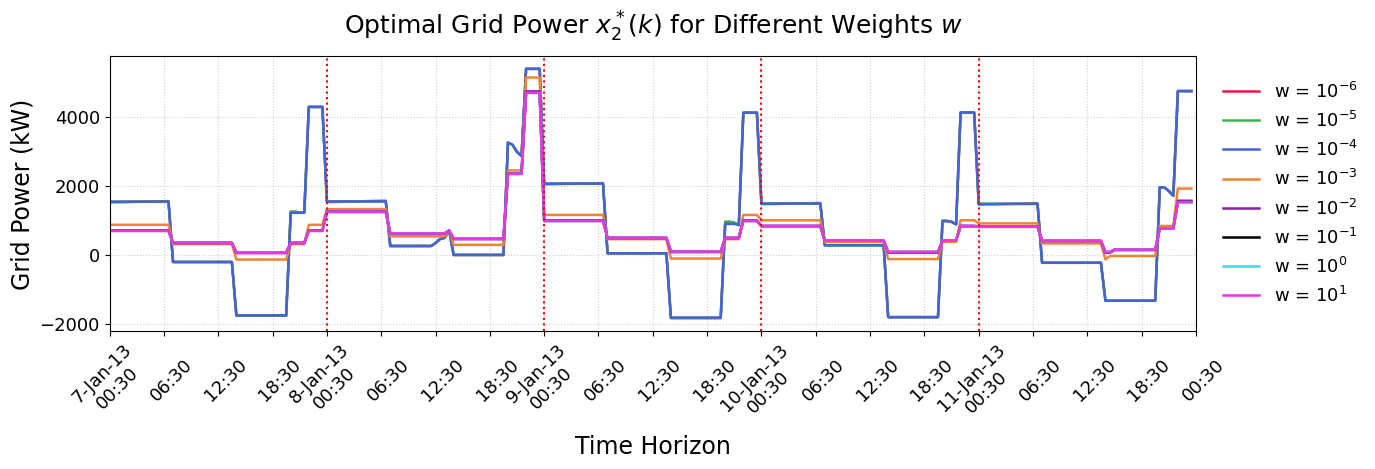

           w    w_value  Total_Savings_$  Grid_Power_StdDev_kW
0  $10^{-6}$   0.000001     17955.001459           1715.524072
1  $10^{-5}$   0.000010     17955.007503           1715.512941
2  $10^{-4}$   0.000100     17922.887627           1713.674883
3  $10^{-3}$   0.001000      7072.974933            789.759929
4  $10^{-2}$   0.010000      5590.742056            679.266835
5  $10^{-1}$   0.100000      5441.216559            668.826473
6   $10^{0}$   1.000000      5426.264009            667.790110
7   $10^{1}$  10.000000      5424.768753            667.686552


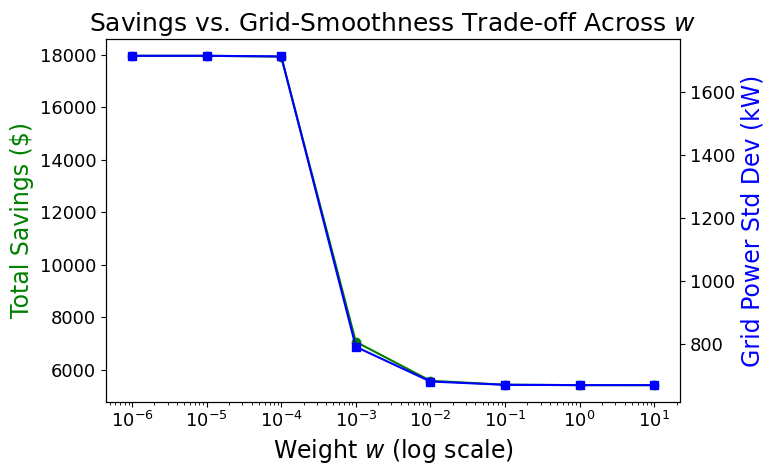

In [4]:
"""
MAIN EXECUTION: Weight Sweep
============================================================
No changes needed -- just run this cell. It will:
  1. Load the perfect load/PV data and tariff, and set the fixed BESS
     parameters (same values as Task 1).
  2. Sweep w across powers of 10 from 10^-6 to 10^1, solving the full 5-day
     QP once per value of w.
  3. Plot the BESS power trajectories x1*(k) overlaid for all tested w.
  4. Plot the grid power trajectories x2*(k) overlaid for all tested w.
  5. Compute and plot the savings-vs-grid-smoothness trade-off across w.
"""

# Configuration parameters
steps_per_day = 48
delta = 0.5   # Corresponds to DELTA_HOURS

### ---- Load data (same as Task 1) ----
filename = 'optimal_BESS_perfect.csv'
load_csv_path = 'perfect_load.csv'
pv_csv_path = 'perfect_pv.csv'

load_profiles, pv_profiles, days, dates = read_load_generation(load_csv_path, pv_csv_path)
total_horizon = days * steps_per_day
eta_profiles = generate_eta_profiles(days, steps_per_day)

### BESS parameters (same as Task 1) -- these stay fixed while w is swept
total_customers = 1330
p_min = -5.0 * total_customers
p_max = 5.0 * total_customers
c_max = 10.0 * total_customers
z_init = 5.0 * total_customers

time_indices_total = np.arange(total_horizon)
timeline_hours = time_indices_total * delta

# ==============================================================================
# SECTION: Sweep over weight w
# ==============================================================================
### Powers of 10, sampled densely at the small end (where the schedule
### changes the most between neighbouring values of w) and sparsely at the
### large end (where the trajectories have already flattened out).
w_exponents = [-6, -5, -4, -3, -2, -1, 0, 1]   # w = 10^exponent
w_values = [10.0 ** e for e in w_exponents]
w_labels = [f"$10^{{{e}}}$" for e in w_exponents]   # e.g. "$10^{-4}$"
results = {}   # w -> (x1, x2, z)

for w in w_values:
    print(f"Solving batch QP for w = {w:.0e} ...")
    x1_w, x2_w, z_w = run_batch_loop(
        z_init, days, steps_per_day, total_horizon, delta,
        load_profiles, pv_profiles, eta_profiles, p_min, p_max, c_max, w
    )
    results[w] = (x1_w, x2_w, z_w)

# ==============================================================================
# SECTION: Plot configuration (shared by both trajectory figures below)
# ==============================================================================
plt.rcParams.update({
    'font.size': 15,
    'axes.labelsize': 17,
    'axes.titlesize': 18,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'savefig.dpi': 300
})

total_hours = timeline_hours[-1] + delta
tick_hours = np.arange(0, total_hours + 1, 6)
time_labels = []
for h in tick_hours:
    day_idx = int(h // 24)
    time_str = f"{int(h % 24):02d}:30"
    if h % 24 == 0 and day_idx < days:
        time_labels.append(f"{dates[day_idx]}\n{time_str}")
    else:
        time_labels.append(f"\n{time_str}")

# Strong, easily distinguishable colors (avoid similar-looking shades)
strong_colors = ['#e6194B', '#3cb44b', '#4363d8', '#f58231', '#911eb4',
                  '#000000', '#42d4f4', '#f032e6', '#808000']
colors = strong_colors[:len(w_values)]

### ==============================================================================
### Figure 1: overlaid BESS power trajectories for different w
### ==============================================================================
plt.figure(figsize=(14, 5))
for (w, label, color) in zip(w_values, w_labels, colors):
    x1_w, _, _ = results[w]
    plt.plot(timeline_hours, x1_w, linestyle='-', linewidth=1.8,
             color=color, label=f'w = {label}')
for d in range(1, days):
    plt.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=1.5)
plt.title('Optimal BESS Power $x_1^*(k)$ for Different Weights $w$', y=1.05)
plt.xlabel('Time Horizon')
plt.ylabel('BESS Power (kW)')
plt.xlim(0, total_hours)
plt.xticks(tick_hours, time_labels, rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

### ==============================================================================
### Figure 2: overlaid grid power trajectories for different w
### ==============================================================================
plt.figure(figsize=(14, 5))
for (w, label, color) in zip(w_values, w_labels, colors):
    _, x2_w, _ = results[w]
    plt.plot(timeline_hours, x2_w, linestyle='-', linewidth=1.8,
             color=color, label=f'w = {label}')
for d in range(1, days):
    plt.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=1.5)
plt.title('Optimal Grid Power $x_2^*(k)$ for Different Weights $w$', y=1.05)
plt.xlabel('Time Horizon')
plt.ylabel('Grid Power (kW)')
plt.xlim(0, total_hours)
plt.xticks(tick_hours, time_labels, rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

### ==============================================================================
### Figure 3: Quantify the trade-off -- savings vs. grid-power smoothness
### A low standard deviation of x2(k) means the grid power stays close to its
### average (a smooth, peak-clipped profile); a high standard deviation means
### it swings widely between large imports and large exports -- the
### reverse-power/voltage-rise risk the quadratic penalty term is meant to
### suppress. This plot shows directly how much savings is traded away for a
### smoother grid interaction as w increases.
### ==============================================================================
savings_list = []
grid_std_list = []
for w in w_values:
    x1_w, x2_w, _ = results[w]
    savings = delta * np.sum(eta_profiles * x1_w)          # net operational savings
    grid_smoothness = np.std(x2_w)                          # proxy for voltage/network stress
    savings_list.append(savings)
    grid_std_list.append(grid_smoothness)

df_tradeoff = pd.DataFrame({
    'w': w_labels,
    'w_value': w_values,
    'Total_Savings_$': savings_list,
    'Grid_Power_StdDev_kW': grid_std_list
})
print(df_tradeoff)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(w_values, savings_list, 'o-', color='green', label='Total Savings ($)')
ax1.set_xscale('log')
ax1.set_xlabel('Weight $w$ (log scale)')
ax1.set_ylabel('Total Savings ($)', color='green')
ax2 = ax1.twinx()
ax2.plot(w_values, grid_std_list, 's-', color='blue', label='Grid Power Std Dev (kW)')
ax2.set_ylabel('Grid Power Std Dev (kW)', color='blue')
plt.title('Savings vs. Grid-Smoothness Trade-off Across $w$')
fig.tight_layout()
plt.show()
